# Hands-On with Real Data: Autoencoders and Generative Adversarial Network (Vanila Encoder Version)


## Objectives
- Implement and train Vanilla Autoencoder, Variational Autoencoder (VAE), and Generative Adversarial Network
(GAN) models.
- Preprocess and explore MNIST, Fashion-MNIST, and a combined dataset (MNIST + Fashion-MNIST).
- Generate synthetic images using each trained model.
- Compare the quality and characteristics of generated images across datasets and models.
- Analyze the impact of training on single vs. combined datasets.
- Use visualization techniques to interpret results

## Dataset Description 
We will work with two commonly used image datasets:
- **Fashion-MNIST:** Fashion item images (10 classes), 28×28 pixels, 60,000 training and 10,000 test. 
- **MNIST:** Handwritten digits (0–9), 28×28 pixels, 60,000 training and 10,000 test images 
- **Combined dataset:** You will also create a combined dataset by concatenating the MNIST and Fashion-MNIST 
sets. 

# Implementation

***Imports***

In [1]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from keras import ops
import numpy as np
import keras

## Step 1: Data Loading and Preprocessing

#### **download the datasets using keras**

In [2]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

(x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
print(np.unique(y_train_fmnist))
y_train_fmnist = np.array(y_train_fmnist)
y_train_fmnist += 10
print(np.unique(y_train_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


In [4]:
print(np.unique(y_test_fmnist))
y_test_fmnist = np.array(y_test_fmnist)
y_test_fmnist += 10
print(np.unique(y_test_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


#### **Normalize Data**

In [5]:
x_train_mnist_normalized = x_train_mnist / 255.0
x_test_mnist_normalized = x_test_mnist / 255.0

x_train_fmnist_normalized = x_train_fmnist / 255.0
x_test_fmnist_normalized = x_test_fmnist / 255.0

#### **Combine into a single dataset**

In [6]:
x_train_combined = np.concatenate([x_train_mnist_normalized, x_train_fmnist_normalized], axis=0)
y_train_combined = np.concatenate([y_train_mnist, y_train_fmnist], axis=0)

x_test_combined = np.concatenate([x_test_mnist_normalized, x_test_fmnist_normalized], axis=0)
y_test_combined = np.concatenate([y_test_mnist, y_test_fmnist], axis=0)

#### **Explore the datasets**

In [7]:
def plot_images_single_dataset(original_images, class_lables, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 3))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{class_lables[i]}]")
        plt.axis('off')

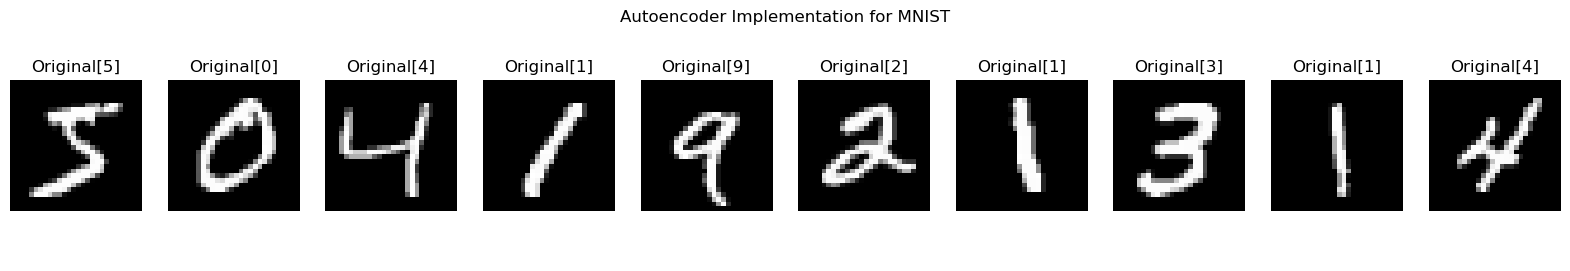

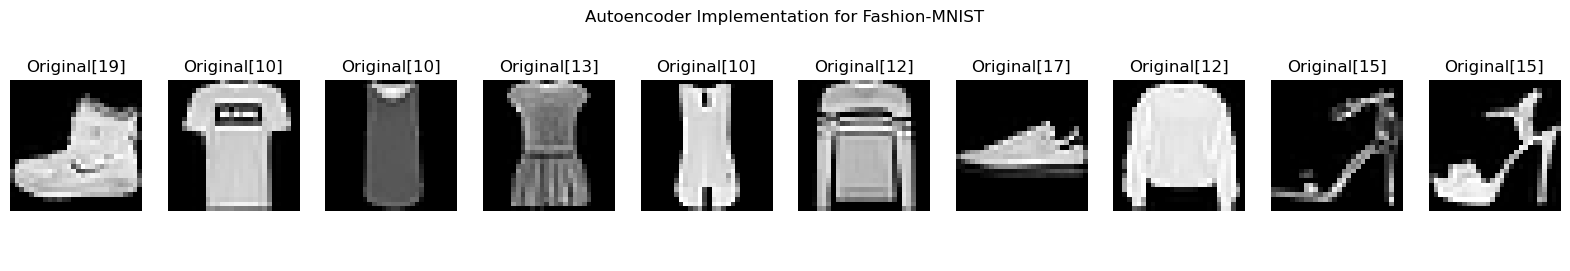

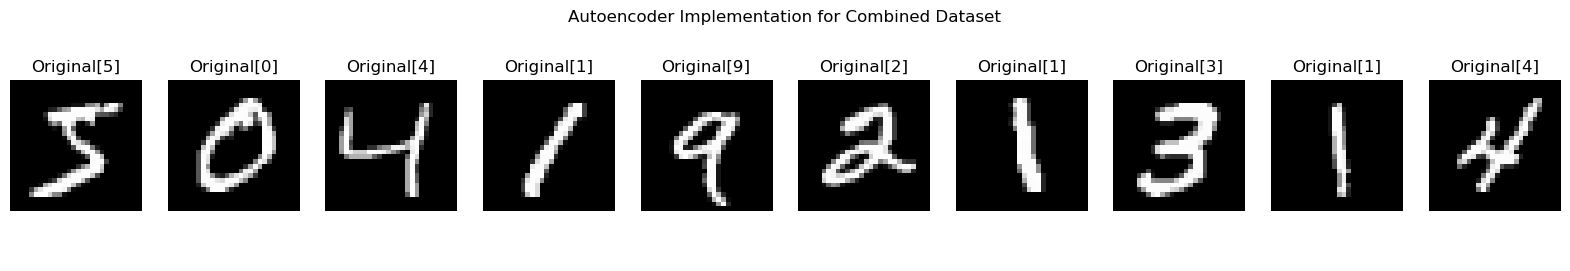

In [8]:
plot_images_single_dataset(x_train_mnist, y_train_mnist, 10, "MNIST")
plot_images_single_dataset(x_train_fmnist, y_train_fmnist, 10, "Fashion-MNIST")
plot_images_single_dataset(x_train_combined, y_train_combined, 10, "Combined Dataset")

Histogram of Class in MNIST

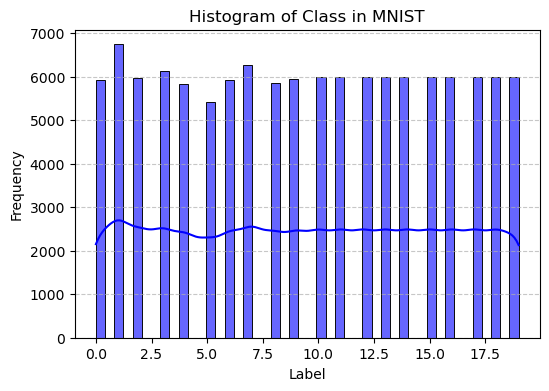

In [9]:
def plot_histogram(column_data, default_bin=10, dataset="MNIST"):
    iqr = np.percentile(column_data, 75) - np.percentile(column_data, 25)
    bin_width_fd = 2 * iqr / (len(column_data) ** (1 / 3))
    if bin_width_fd > 0:
        n_bins_fd = int(np.ceil((column_data.max() - column_data.min()) / bin_width_fd))
    else:
        n_bins_fd = default_bin

    plt.figure(figsize=(6, 4))
    sns.histplot(column_data, bins=n_bins_fd, kde=True, color="blue", alpha=0.6)
    plt.title(f'Histogram of Class in {dataset}')
    plt.xlabel('Label')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_histogram(y_train_combined)

#### **Comment on differences between the datasets and potential challenges when combining them.**

---

One of the main potential issues we noticed was that both MNIST and Fashion-MNIST use integer labels from 0-9, but they represent different things: digits and clothing). If we simply concatenate them, class 0 will be automatically assigned to both 0 and the t-shirt. To prevent this from happening, we can re mapping the labels so that the combined dataset has classes from 0 to 19 (20 classes for both datasets). The other difference is that MNIST digits are simple strokes while Fashion-MNIST items have more complex textures and shapes. 

---

## Step 2.1: Train Vanilla Autoencoder Models (Fully Connected Network Version)


#### **Split the Train and Validation Data**

In [10]:
x_train_mnist, x_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    x_train_mnist_normalized, y_train_mnist, test_size=0.3, random_state=42
)

x_train_fmnist, x_val_fmnist, y_train_fmnist, y_val_fmnist = train_test_split(
    x_train_fmnist_normalized, y_train_fmnist, test_size=0.3, random_state=42
)

x_train_combined, x_val_combined, y_train_combined, y_val_combined = train_test_split(
    x_train_combined, y_train_combined, test_size=0.3, random_state=42
)

#### **Reshape the dataset**

MNIST

In [11]:
x_train_mnist_reshape = x_train_mnist.reshape(-1, x_train_mnist.shape[1] * x_train_mnist.shape[2])
x_val_mnist_reshape = x_val_mnist.reshape(-1, x_val_mnist.shape[1] * x_val_mnist.shape[2])
x_test_mnist_reshape = x_test_mnist.reshape(-1, x_test_mnist.shape[1] * x_test_mnist.shape[2])

Fashion-MNIST

In [12]:
x_train_fmnist_reshape = x_train_fmnist.reshape(-1, x_train_fmnist.shape[1] * x_train_fmnist.shape[2])
x_val_fmnist_reshape = x_val_fmnist.reshape(-1, x_val_fmnist.shape[1] * x_val_fmnist.shape[2])
x_test_fmnist_reshape = x_test_fmnist.reshape(-1, x_test_fmnist.shape[1] * x_test_fmnist.shape[2])

Combined Dataset

In [13]:
x_train_combined_reshape = x_train_combined.reshape(-1, x_train_combined.shape[1] * x_train_combined.shape[2])
x_val_combined_reshape = x_val_combined.reshape(-1, x_val_combined.shape[1] * x_val_combined.shape[2])
x_test_combined_reshape = x_test_combined.reshape(-1, x_test_combined.shape[1] * x_test_combined.shape[2])

#### **Create the Dictionary Labels**

MNIST

In [14]:
uniques_mnist = np.unique(y_train_mnist)
list_lables_mnist = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
dict_labels_mnist = {i: list_lables_mnist[i] for i in range(len(list_lables_mnist))}
dict_labels_mnist

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9'}

Fashion MNIST

In [15]:
uniques_fminst = np.unique(y_train_fmnist)
list_lables_fminst = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
dict_labels_fminst = {i+10: list_lables_fminst[i] for i in range(len(list_lables_fminst))}
dict_labels_fminst

{10: 'T-shirt/top',
 11: 'Trouser',
 12: 'Pullover',
 13: 'Dress',
 14: 'Coat',
 15: 'Sandal',
 16: 'Shirt',
 17: 'Sneaker',
 18: 'Bag',
 19: 'Ankle boot'}

#### **Vanilla Encoder (For Single Dataset Version)**

In [47]:
def create_vanilla_autoencoder(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    enconder_input_layer = layers.Dense(input_dim, activation='relu')(encoder_inputs)
    enconder_hidden_layer = layers.Dense(128, activation='relu')(enconder_input_layer)
    enconder_output_layer = layers.Dense(latent_dim, activation='relu')(enconder_hidden_layer)
    encoder = Model(encoder_inputs, enconder_output_layer, name='encoder')

    decoder_inputs = layers.Input(shape=(latent_dim,))
    decoder_inputs_layer = layers.Dense(latent_dim, activation='relu')(decoder_inputs)
    decoder_hidden_layer = layers.Dense(128, activation='relu')(decoder_inputs_layer)
    decoder_output_layer = layers.Dense(input_dim, activation='sigmoid')(decoder_hidden_layer)    
    decoder = Model(decoder_inputs, decoder_output_layer, name='decoder')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder, encoder, decoder

In [48]:
def plot_reconstructions_images_single_dataset(original_images, reconstructed_images, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 6))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(2, num_images, i + num_images + 1)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')
    plt.show()

#### **MNIST**

Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1296 - val_loss: 0.0689
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0673 - val_loss: 0.0651
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0645 - val_loss: 0.0640
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0636 - val_loss: 0.0633
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0627 - val_loss: 0.0625
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0623 - val_loss: 0.0622
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0618 - val_loss: 0.0615
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0611 - val_loss: 0.0615
Epoch 9/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0609 - val_loss: 0.0593
Epoch 10/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0589 - val_loss: 0.0571
Epoch 11/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0563 - val_loss: 0.0552
Epoch 12/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0

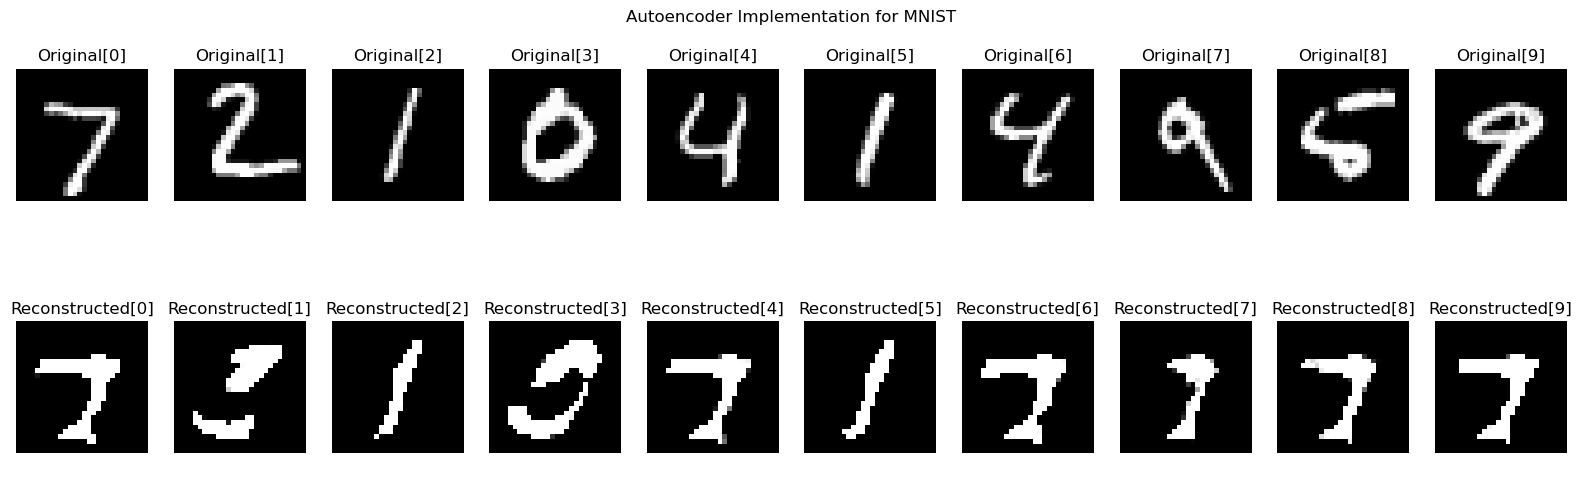

In [50]:
def autoencoder_mnist_implementation(x_train_mnist_input, x_val_mnist_input, x_test_mnist_input):
    input_dim = x_train_mnist_input.shape[1]
    latent_dim = 2

    autoencoder_mnist, encoder_mnist, decoder_mnist = create_vanilla_autoencoder(input_dim, latent_dim)

    autoencoder_mnist.fit(
        x_train_mnist_input,
        x_train_mnist_input,
        epochs=30,
        batch_size=512,
        validation_data=(x_val_mnist_input, x_val_mnist_input)
    )

    reconstructed_images = autoencoder_mnist.predict(x_test_mnist_input)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_mnist_input, reconstructed_images).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist, encoder_mnist, decoder_mnist, reconstructed_images

autoencoder_mnist, encoder_mnist, decoder_mnist, reconstructed_images = autoencoder_mnist_implementation(x_train_mnist_reshape, x_val_mnist_reshape, x_test_mnist_reshape)
plot_reconstructions_images_single_dataset(x_test_mnist_reshape, reconstructed_images, num_images=10, dataset_name='MNIST')

#### **Fashion-MNIST**

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1258 - val_loss: 0.0788
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0772 - val_loss: 0.0739
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0718 - val_loss: 0.0514
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0466 - val_loss: 0.0407
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0397 - val_loss: 0.0386
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0376 - val_loss: 0.0369
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0367 - val_loss: 0.0365
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0364 - val_loss: 0.0362
Epoch 9/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0362 - val_loss: 0.0356
Epoch 10/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0354 - val_loss: 0.0355
Epoch 11/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0351 - val_loss: 0.0350
Epoch 12/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 

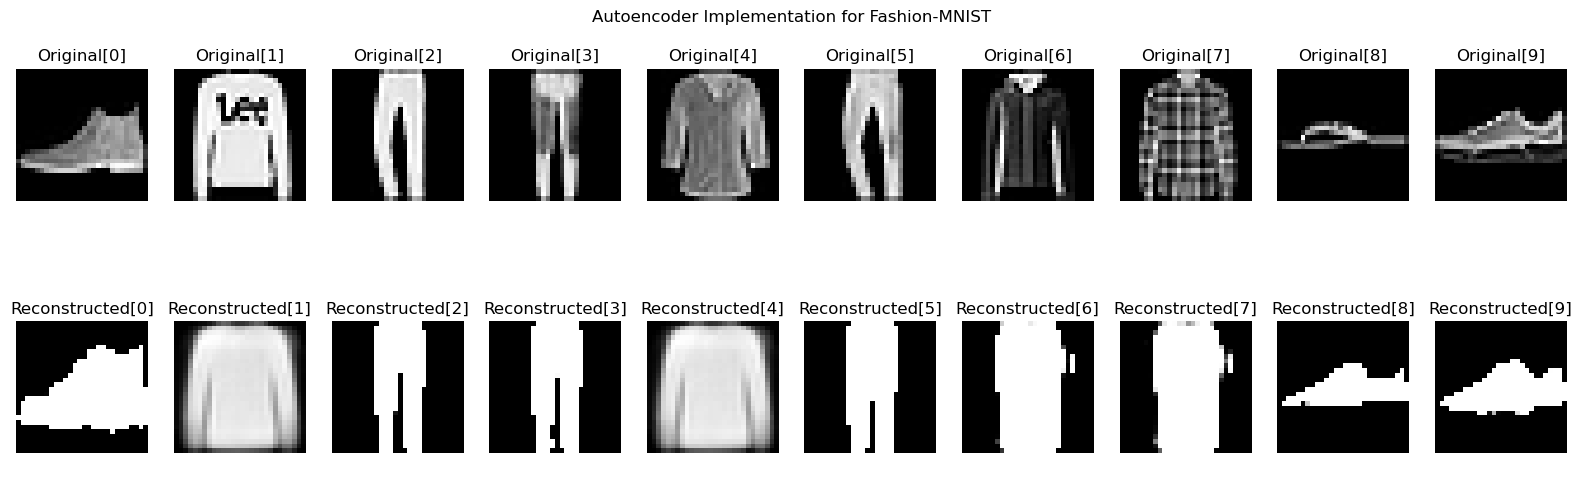

In [51]:
def autoencoder_mnist_fashion_implementation(x_train_fmnist_fashsion_input, x_val_fmnist_fashsion_input, x_test_fmnist_fashsion_input):
    input_dim = x_train_fmnist_fashsion_input.shape[1]
    latent_dim = 2

    autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion = create_vanilla_autoencoder(input_dim, latent_dim)

    autoencoder_mnist_fashion.fit(
        x_train_fmnist_fashsion_input,
        x_train_fmnist_fashsion_input,
        epochs=30,
        batch_size=256,
        validation_data=(x_val_fmnist_fashsion_input, x_val_fmnist_fashsion_input)
    )

    reconstructed_images_fashion = autoencoder_mnist_fashion.predict(x_test_fmnist_fashsion_input)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_fmnist_fashsion_input, reconstructed_images_fashion).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion, reconstructed_images_fashion

autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion, reconstructed_images_fashion = autoencoder_mnist_fashion_implementation(x_train_fmnist_reshape, x_val_fmnist_reshape, x_test_fmnist_reshape)
plot_reconstructions_images_single_dataset(x_test_fmnist_reshape, reconstructed_images_fashion, num_images=10, dataset_name='Fashion-MNIST')

#### **Vanilla Encoder (For Combined Dataset Version)**

#### Combined Data

In [53]:
def create_vanilla_autoencoder_combined_version(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim, activation='relu')(encoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(latent_dim, activation='relu')(x)
    encoder = Model(encoder_inputs, x, name='encoder')

    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(latent_dim, activation='relu')(decoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(input_dim, activation='sigmoid')(x)    
    decoder = Model(decoder_inputs, x, name='decoder')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder, encoder, decoder

In [54]:
def plot_reconstructions_images_combined_dataset(original_images, reconstructed_images, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 10))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(4, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(4, num_images, i + num_images + 1)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')

    for i in range(num_images):
        ax = plt.subplot(4, num_images, i + num_images * 2 + 1)
        plt.imshow(original_images[-i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(4, num_images, i + num_images * 3 + 1)
        plt.imshow(reconstructed_images[-i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')

    plt.show()

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.1897 - val_loss: 0.1613
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1535 - val_loss: 0.1353
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1302 - val_loss: 0.1188
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1157 - val_loss: 0.1083
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1062 - val_loss: 0.1016
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1002 - val_loss: 0.0972
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0961 - val_loss: 0.0942
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0932 - val_loss: 0.0921
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0915 - val_loss: 0.0906
Epoch 10/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0902 - val_loss: 0.0895
Epoch 11/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0892 - val_loss: 0.0888
Epoch 12/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/ste

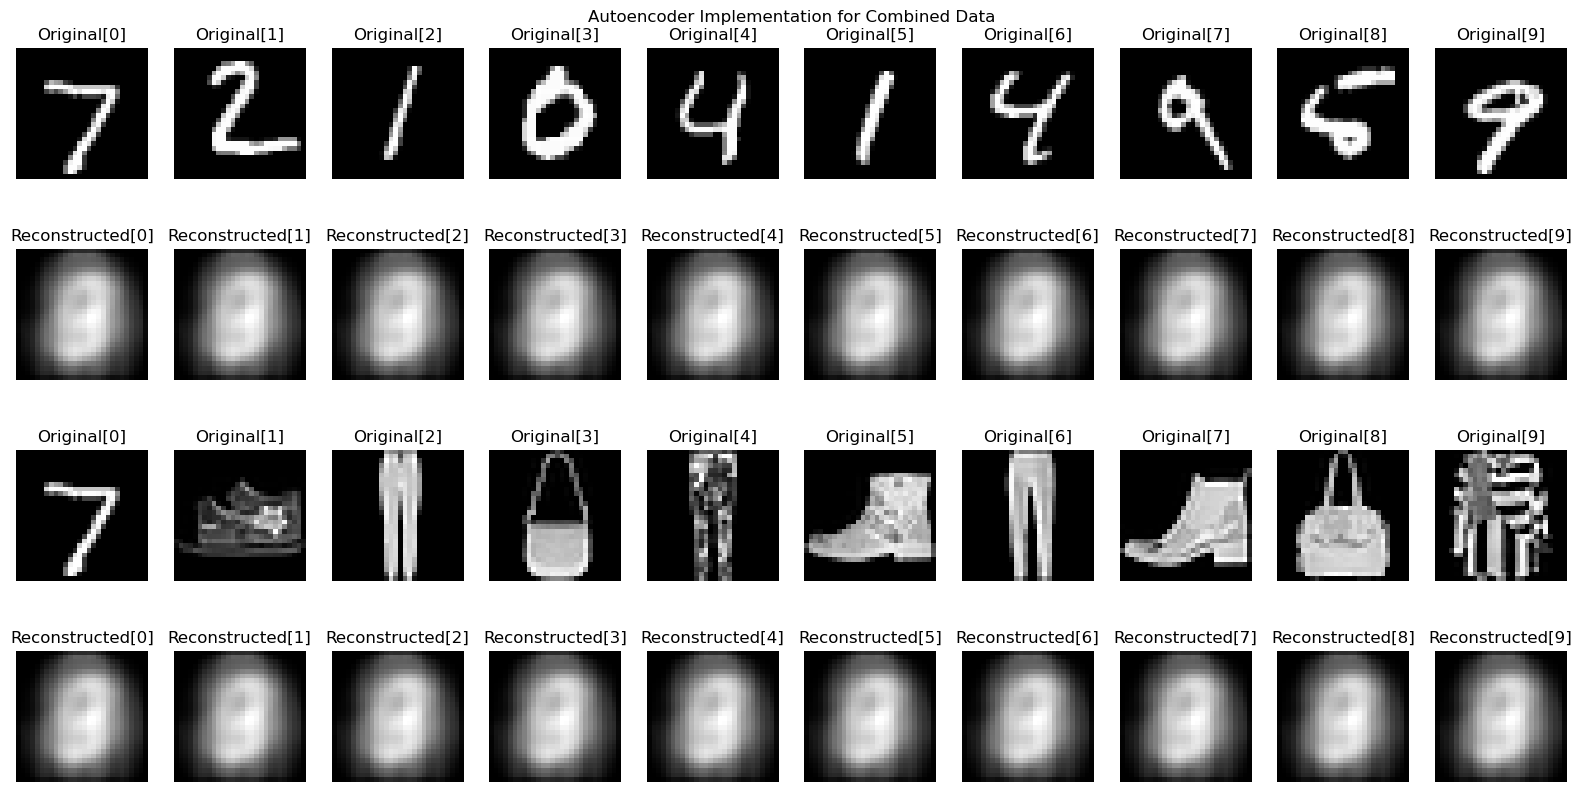

In [55]:
def autoencoder_mnist_combined_implementation(x_train_combined_normalized, x_val_combined_normalized, x_test_combined_normalized):
    input_dim = x_train_combined_normalized.shape[1]
    latent_dim = 2

    autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined = create_vanilla_autoencoder_combined_version(input_dim, latent_dim)

    autoencoder_mnist_combined.fit(
        x_train_combined_normalized,
        x_train_combined_normalized,
        epochs=50,
        batch_size=256,
        validation_data=(x_val_combined_normalized, x_val_combined_normalized)
    )

    reconstructed_images_combined = autoencoder_mnist_combined.predict(x_test_combined_normalized)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_combined_normalized, reconstructed_images_combined).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined, reconstructed_images_combined

autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined, reconstructed_images_combined = autoencoder_mnist_combined_implementation(x_train_combined_reshape, x_val_combined_reshape, x_test_combined_reshape)
plot_reconstructions_images_combined_dataset(x_test_combined_reshape, reconstructed_images_combined, num_images=10, dataset_name='Combined Data')